#  实现Agent
区分两种类型的AI系统
- Router：没有循环
- Agent：ReAct架构，支持循环

## 新东西
parallel_tool_call:是否并行调用,数学计算不适合并行调用
防止无限思考循环：给循环设置最大循环次数

## 本章节实现
一个模型和工具循环的agent系统
要求：
- 进行加减乘运算
- llm-》工具，工具-〉llm

### 步骤
- 定义llm client
- 定义3个计算工具类
- 绑定工具到llm实例
- 创建决策节点
- 创建图，注册决策节点/工具节点，绘制边，编译并打印结构
- 测试图


### 进度
今天看到流失输出，明天接着看

In [2]:

# 通用步骤
from langchain_openai import ChatOpenAI


glm_client = ChatOpenAI(
    api_key="d1de7475090740ebb6c887167a6a8b98.2WUSfYbmgQwYLKF4",
    base_url="https://open.bigmodel.cn/api/paas/v4/",
    model="glm-4.7",
)

In [3]:
def multipy(a:int,b:int)->int:
    """计算 a 和 b 的乘积
    
    Args:
        a : 第一个参数
        b : 第二个参数

    Returns:
        a * b 的计算结果
    """
    return a * b

def divide(a:int , b:int)->int:
    """计算 a 和 b 的差值

    Args:
        a: first num
        b: second num
    
    Returns:
        a 减去 b 的运算结果
    """
    return a - b

def add(a:int , b:int)->int:
    """计算 a 和 b 的和
    
    Args:
        a:first num
        b:second num

    Returns:
        a 和 b的和
    """
    return a + b

In [ ]:
# 绑定工具到llm实例上
tools = [add , divide, multipy]
glm_client_with_tool = glm_client.bind_tools(tools,parallel_tool_call=False)

In [5]:
# 创建决策节点
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage

def node_decide(state:MessagesState):
    sys_message = SystemMessage(content="你是一个用于数学计算的小助手")
    messages = [sys_message] + state["messages"]
    return {"messages":[glm_client_with_tool.invoke(messages)]}

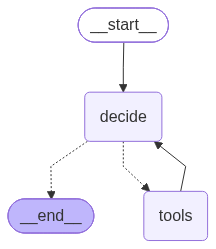

In [6]:
# 创建图
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition


graph  = StateGraph(MessagesState)
graph.add_node("decide", node_decide)
graph.add_node("tools", ToolNode(tools) )

graph.add_edge(START,"decide")
graph.add_conditional_edges("decide", tools_condition)
graph.add_edge("tools", "decide")

app = graph.compile()

from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
from langchain_core.messages import HumanMessage
# 测试一下复杂运算
res = app.invoke({"messages":[HumanMessage(content="计算一下5 + 8 * 5 -10")]})

In [8]:
for msg in res["messages"]:
    msg.pretty_print()

================================ Human Message =================================

计算一下5 + 8 * 5 -10
================================== Ai Message ==================================

我来帮您计算 5 + 8 * 5 - 10。

按照运算顺序，我先计算乘法部分 8 * 5：
Tool Calls:
  multipy (call_-7347507308974308660)
 Call ID: call_-7347507308974308660
  Args:
    a: 8
    b: 5
================================= Tool Message =================================
Name: multipy

40
================================== Ai Message ==================================
Tool Calls:
  add (call_-7347608979440139683)
 Call ID: call_-7347608979440139683
  Args:
    a: 5
    b: 40
================================= Tool Message =================================
Name: add

45
================================== Ai Message ==================================
Tool Calls:
  divide (call_-7347616126265716618)
 Call ID: call_-7347616126265716618
  Args:
    a: 45
    b: 10
================================= Tool Message =================================
